In [4]:
%load_ext ipympl
%matplotlib widget

# pip install casadi numpy
import casadi as ca
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.animation import PillowWriter
import imageio.v3 as iio

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

import ipywidgets as W


from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from matplotlib.patches import Wedge

import importlib, game_sharedutils, game_2dutils, game_3dutils, game_costs
importlib.reload(game_sharedutils)
importlib.reload(game_2dutils)
importlib.reload(game_3dutils)
importlib.reload(game_costs)


from game_sharedutils import dims_from_D
from game_2dutils    import solve_game_once_2d, plot_planned_trajectories_2d, run_rhc_and_collect_frames_2d
from game_3dutils    import solve_game_once_3d, plot_planned_trajectories_3d, run_rhc_and_collect_frames_3d, animate_rollout_3d,interactive_rollout_3d
from game_costs import build_costs


The ipympl module is not an IPython extension.


In [ ]:
# -----------------------------------------------------------------------------
# Config and notation
# -----------------------------------------------------------------------------
# State x = [px, py, vx, vy]ᵀ: position (px, py) and velocity (vx, vy)
# Control u = [ax, ay]ᵀ: acceleration inputs
# Horizon length T: number of state samples (there are T-1 control samples)
# Players: N=2 (player 1, player 2). Trajectories for each player i are packed into τᵢ.
# τ = [τ₁; τ₂]: concatenation of both players’ trajectories.
# θ (“theta”): parameter vector containing the stacked initial states for both players.
#
# We form a “variational inequality” style equilibrium by enforcing stationarity of each
# player’s Lagrangian w.r.t. its own τᵢ, plus shared dynamics/IC constraints g̃(τ,θ)=0
# and shared inequalities h̃(τ,θ) ≥ 0 (arena, bounds, separation, obstacles).
# -----------------------------------------------------------------------------


CONFIG = {
    # --- scenario / time ---
    "setting":  "chase_escape_tail",
    "D":        3,
    "T":        10,
    "dt":       0.1,
    "sim_time": 45.0,

    # --- dynamics (choose: "double" or "hcw") ---
    "dynamics": "hcw",
    "hcw": {  # compute n = sqrt(mu/r0^3)
        "mu": 3.986004418e14,                 # m^3/s^2 (Earth)
        "r0": 6_371_000.0 + 400_000.0,        # m (Earth radius + altitude)
        # (you can instead pass "n": <rad/s> directly if you prefer)
    },

    # --- initial states: rows = agents, cols = [px,py,pz,vx,vy,vz] ---
    "x0": np.array([
        [ 1.0,  2.8, -0.4,  0.00, 0.00, 0.00],
        [-1.0,  -2.8,  0,  0.00, 0.002, 0.00],
    ], dtype=float),

    # --- workspace / constraints ---
    "arena": {"type": "sphere", "cx": 0.0, "cy": 0.0, "cz": 0.0, "r": 3.0},
    "vmax":   5.0,
    "umax":   10.0,
    "sep_min": 0.1,

    # optional 3D keep-out obstacles (must lie inside arena)
    "spheres": [
        # {"cx": 0.0, "cy": 0.0, "cz": 0.0, "r": 1.0},
    ],

    # --- field of view (used for visibility + drawing) ---
    "fov": {
        "enabled": True,
        "agent": 1,                 # which agent has the FOV (2 = defender)
        "range": 1.0,               # meters
        "hfov_deg": 60.0,           # total cone angle
        "min_speed_for_axis": 1e-3, # hold boresight when slower than this
        "color": "C1",
        "alpha": 0.15
    },

    # --- attitude (boresight aligned with velocity; roll about x̂_b) ---
    "att": {
        "mode": "hold",             # "hold" | "rate" | "track" (step_phi uses this)
        "phi0": np.pi/2,                # initial roll angle [rad]
        # For "rate" mode:   set "phi_rate": <rad/s>
        # For "track" mode:  set "phi_target": <rad>, "tau": <s>
        "align": "x",               # boresight is x̂ in body frame
        "up": [0.0, 0.0, 1.0],      # world up used to construct triad
        "min_speed_for_axis": 1e-3  # same logic as FOV; safe to keep duplicated here
    },

    # "viz": {
    #     "triad_colors": ("tab:red","tab:green","tab:blue"),
    #     "triad_labels": ("x_b (boresight)","y_b","z_b"),
    #     "triad_leg_loc": "lower left",
    #     "triad_leg_ncol": 3,
    #     "triad_leg_title": "Body axes"
    # },

    # --- optional orbit-style task knobs (unused by core solver unless your cost reads them) ---
    # "orbit_axis": [0, 0, 1],
    # "omega_target": 0.5,
    # "plane_lock_w": 0.0,
    # "radial_lock_w": 0.0,
}

# CONFIG["setting"] = "fov_tag_simple"
# CONFIG["dynamics"] = "hcw"   # start simple; HCW later if needed
# CONFIG["T"] = 8                 # shorter horizon helps speed/stability
# CONFIG["dt"] = 0.15

# # Optional: weights for this game
# CONFIG["fov_cost"] = {
#     "w_ang2": 1.0,   # P2 aims its boresight at P1
#     "w_dist2": 0.2,  # P2 prefers closeness
#     "w_far1": 1.0,   # P1 prefers distance
#     "w_ang1": 0.5,   # P1 prefers misalignment
# }

# # Gentle effort regularization
# CONFIG["effort_w1"] = 0.01
# CONFIG["effort_w2"] = 0.01

# ipopt_opts = {
#     "ipopt.max_iter": 200,
#     "ipopt.tol": 1e-3,
#     "ipopt.acceptable_tol": 1e-2,
#     "ipopt.print_level": 0,
#     "print_time": 0,
# }





[3D] Objective residual (0.5||G||^2): 1.315e-02
[3D] z dim: 806 (taus=212, lam=140, mu=454)
Saved 3D animation to traj_3D.gif


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (700, 600) to (704, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved animation to traj_3D.mp4


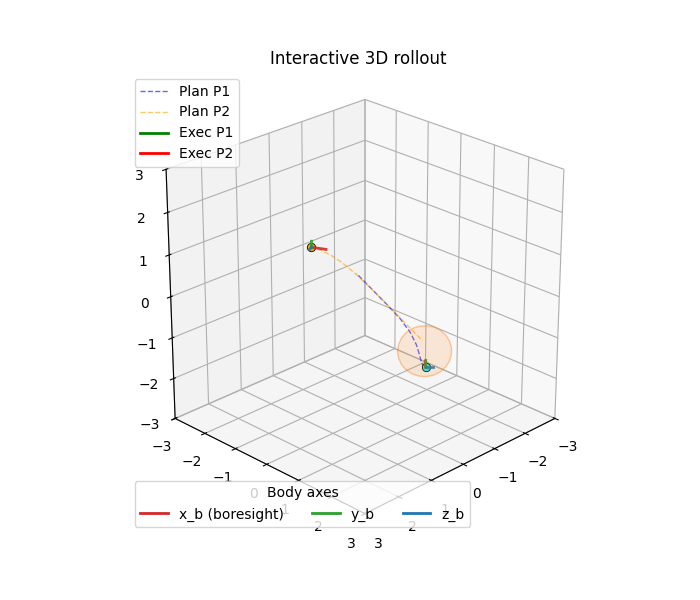

In [8]:
if __name__ == "__main__":
    # 1) Solve once & (optionally) plot
    sol = solve_game_once_3d(cfg=CONFIG, cost_builder=build_costs)
    # plot_planned_trajectories_3d(sol, CONFIG)  # optional

    # 2) Generate rollout DATA
    rollout = run_rhc_and_collect_frames_3d(cfg=CONFIG, cost_builder=build_costs)

    # 3) Make a GIF or MP4 directly from the rollout (pick one)
    # GIF:
    animate_rollout_3d(rollout, save_path="traj_3D.gif", fps=20, cfg=CONFIG, show_fov=True, show_axes=True);

    # MP4 (preferred if ffmpeg is available):
    # animate_rollout_3d(rollout, save_path="traj_3D.mp4", fps=20, cfg=CONFIG, show_fov=True, show_axes=True)

    # If you really want to convert GIF -> MP4 via imageio (not necessary if using the MP4 line above):
    import imageio.v3 as iio
    gif_frames = iio.imread("traj_3D.gif")
    iio.imwrite("traj_3D.mp4", gif_frames, fps=20, codec="h264")
    print("Saved animation to traj_3D.mp4")

    # 4) INTERACTIVE viewer (Jupyter/Colab)
    interactive_rollout_3d(rollout, CONFIG, show_fov=True, show_axes=True)
